# Dipole Antenna Array

In this example we apply array factor approximation to obtain radiation characteristics of antenna arrays.

In [1]:
# Tidy3d import 
import tidy3d as td
from tidy3d import web

# Tidy3d plugin import
import tidy3d.plugins.smatrix as smatrix
from tidy3d.plugins.microwave import RectangularAntennaArrayCalculator

# External modules needed for this notebook
import numpy as np
import matplotlib.pyplot as plt

td.config.logging_level = "ERROR"

Define the operating frequency range and frequency points for recording simulation data.

In [2]:
# Scaling used for millimeters
mm = 1e3 

# Frequency range
freq_start = 5e9
freq_stop = 15e9

freq0 = (freq_start + freq_stop) / 2 # Centeral frequency
freqs_target = np.linspace(freq_start, freq_stop, 5)
fwidth = freq_stop - freq_start # Bandwidth

# Wavelength of centeral frequency in Vaccum
wavelength0 = td.C_0 / freq0

# Frequency sweep for S-parameters
freqs = np.linspace(freq_start, freq_stop, 201)

Define dimensions of the dipole antenna.

In [3]:
# Dipole parameters
dipole_length = 0.47 * wavelength0
dipole_radius = wavelength0 / 150

Compute auxiliary parameters.

In [4]:

dipole_width = dipole_radius * 4
dipole_gap = dipole_width
arm_length = 0.5 * (dipole_length - dipole_gap)
arm_center = 0.5 * arm_length + 0.5 * dipole_gap

pml_buffer = 0.25 * wavelength0

sim_x = dipole_length + 2 * pml_buffer
sim_y = dipole_width + 2 * pml_buffer
sim_z = dipole_width + 2 * pml_buffer

Define materials.

In [5]:
# Material present
air = td.Medium()
eps_r = 2.2
sub_medium = td.Medium(permittivity=eps_r)
PEC = td.PEC2D # Thickness-free PEC medium

Create structures representing dipole arms.

In [6]:
arm_a = td.Structure(
    geometry=td.Box(center=[-arm_center, 0, 0], size=[arm_length, dipole_width, 0]),
    medium=PEC,
)

arm_b = td.Structure(
    geometry=td.Box(center=[arm_center, 0, 0], size=[arm_length, dipole_width, 0]),
    medium=PEC,
)

Define monitors.

In [7]:
# Define observation parameters used for projection monitors
theta = np.linspace(0, np.pi, 101)
phi = np.linspace(0, 2*np.pi, 101)

# Field monitor to view the electromagnetic fields in the dipole plane
monitor_field = td.FieldMonitor(
    center=(0, 0, 0),
    size=(td.inf, td.inf, 0),
    freqs=[freq0],  
    name="field",
)

# Angular projection monitor to view radiation intensity
monitor_projection = td.FieldProjectionAngleMonitor(
    center=[0, 0, 0],
    size=(dipole_length + pml_buffer, dipole_width + pml_buffer, dipole_width + pml_buffer), # We introduce a monitor box to enclose the whole structure of interest
    freqs=freqs_target,   
    name="radiation",
    phi=list(phi),
    theta=list(theta), 
    far_field_approx=False, 
)

# We define a DirectivityMonitor to obatin radiation characteritics such as directivity, axial ratio and polarized far fields.
monitor_directivity = td.DirectivityMonitor(
    center=[0, 0, 0],
    size=monitor_projection.size,
    freqs=freqs_target,   
    name="directivity",
    phi=list(phi),
    theta=list(theta),
    far_field_approx=False,
)

Create simulation specification for the antenna.

In [8]:
# Create the simulation object
sim = td.Simulation(
    center=(0*mm, 0*mm, 0*mm),
    medium=td.Medium(permittivity=4),
    size=[sim_x,sim_y,sim_z],
    grid_spec=td.GridSpec.auto(
        min_steps_per_wvl=20, # The largest cell size is set to 20 cells per smallest wavelength.
        wavelength=td.C_0 / freq_stop, # Smallest wavelength to resolve  
    ),
    structures=[arm_a, arm_b],
    monitors=[monitor_projection, monitor_field, monitor_directivity],
    run_time=100 * (wavelength0 / td.C_0),
    plot_length_units="mm", # This option will make plots default to units of millimeters.
)   

Simulation visualization.

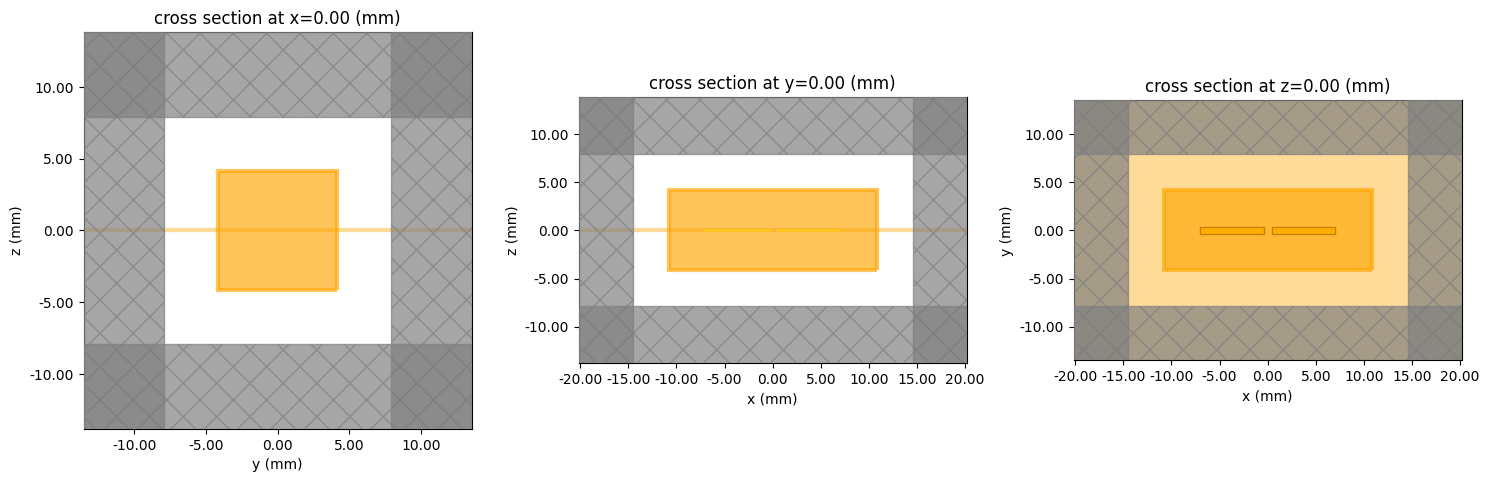

In [9]:
_, ax = plt.subplots(1, 3, figsize=(15, 5))
sim.plot(x=0, ax=ax[0])
sim.plot(y=0, ax=ax[1])
sim.plot(z=0, ax=ax[2])

plt.tight_layout()
plt.show()

Put a lumped port between dipole arms.

In [10]:
# Define the port impedance
port_impedance = 50

# Setup a LumpedPort for the TerminalComponentModeler
port = smatrix.LumpedPort(
    center=[0, 0, 0],
    size=[dipole_gap, dipole_width, 0],
    voltage_axis=0,
    name="lumped_port",
    impedance=port_impedance,
)

# We integrate the base simulation with the LumpedPort using the TerminalComponentModeler.
modeler = smatrix.TerminalComponentModeler(
    simulation=sim,
    ports=[port],
    freqs=freqs,
    verbose=True,
    remove_dc_component=False, # Include DC component for more accuracy at low frequencies
)

sim_unit = list(modeler.sim_dict.values())[0]

Mesh visualization.

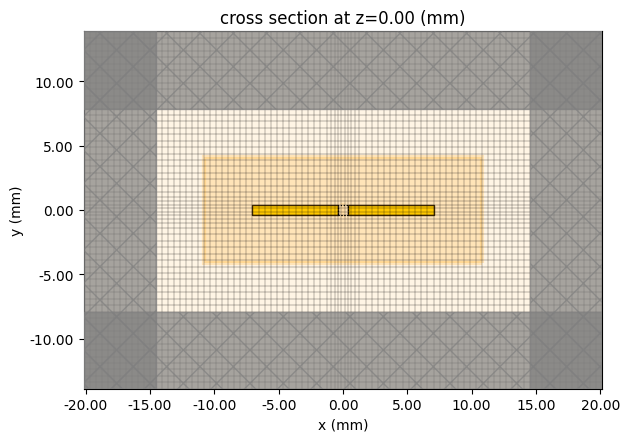

In [11]:
ax = sim_unit.plot(z=0, monitor_alpha=0.1)
sim_unit.plot_grid(z=0, ax=ax, monitor_alpha=0)
plt.show()

Run simulation to obtain radiation parameters of a single antenna.

In [12]:
from tidy3d_backend.run import run_sim

In [ ]:
sim_unit_data = run_sim(sim_unit)

Now we can use Tidy3D convenience functions to approximate radiation characteristics of a phased antenna array based on the results of a single antenna simulation.

Let us define parameters of the array of interest.

In [24]:
# phase array parameters
array_size = [5, 9, 1]
spacings = [0.5 * wavelength0, 0.5 * wavelength0, 0.5 * wavelength0]
phase_shifts = [np.pi / 5, np.pi / 4, 0]

Now we use function `simulation_data_from_array_factor` that converts simulation data from a single antenna into simulation data of a phase array based on pattern multiplication approximation. It only preserves field projection monitors as indicated by warnings.

In [25]:
array_calc = RectangularAntennaArrayCalculator(
    array_size=array_size,
    spacings=spacings,
    phase_shifts=phase_shifts,
    # amp_multipliers=(np.sin(np.pi * np.arange(5) / 4), np.sin(np.pi * np.arange(8) / 7), None)
)

In [26]:
sim_array_data_from_af = array_calc.simulation_data_from_array_factor(
    antenna_data=sim_unit_data,
)

[25-02-21 11:30:33.949][USER   ]: WARNING: Monitor 'field' (type: 'FieldMonitor') will not be       
[25-02-21 11:30:33.949][USER   ]: automatically transferred into the resulting antenna array        
[25-02-21 11:30:33.949][USER   ]: simulation.                                                       
[25-02-21 11:30:33.956][USER   ]: WARNING: Monitor 'lumped_port_voltage' (type: 'FieldMonitor') will
[25-02-21 11:30:33.956][USER   ]: not be automatically transferred into the resulting antenna array 
[25-02-21 11:30:33.956][USER   ]: simulation.                                                       
[25-02-21 11:30:33.961][USER   ]: WARNING: Monitor 'lumped_port_current' (type: 'FieldMonitor') will
[25-02-21 11:30:33.961][USER   ]: not be automatically transferred into the resulting antenna array 
[25-02-21 11:30:33.961][USER   ]: simulation.                                                       
[25-02-21 11:30:34.119][USER   ]: WARNING: Structure at structures[0] was detected as being

Note that this function automatically replaces simulation specification as well. That is, we can use `.simulation` field of the resulting simulation data object to visualize and run simulation for the antenna array.

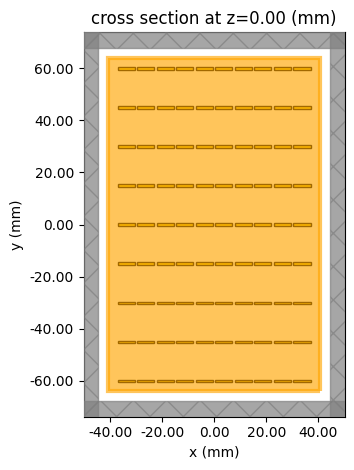

In [17]:
sim_array = sim_array_data_from_af.simulation

ax = sim_array.plot(z=0)
# sim_array.plot_grid(z=0, ax=ax)
plt.show()

In [ ]:
sim_array_data_direct = run_sim(sim_array)

Compare approximated and direct simulation results.

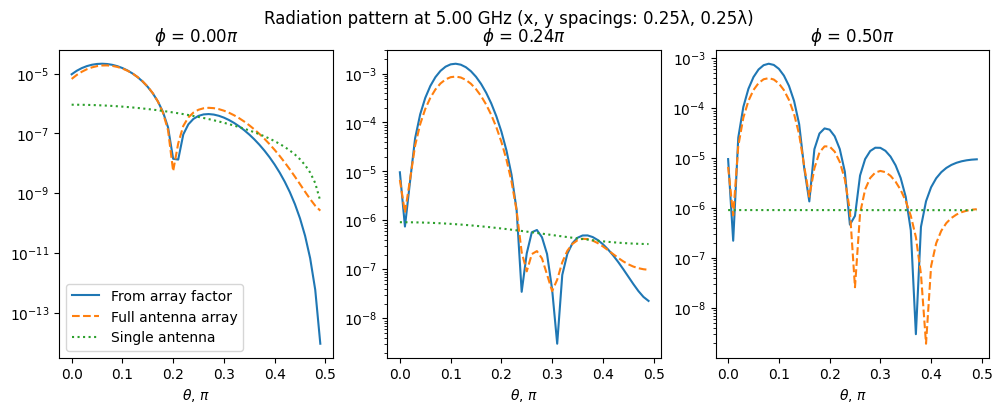

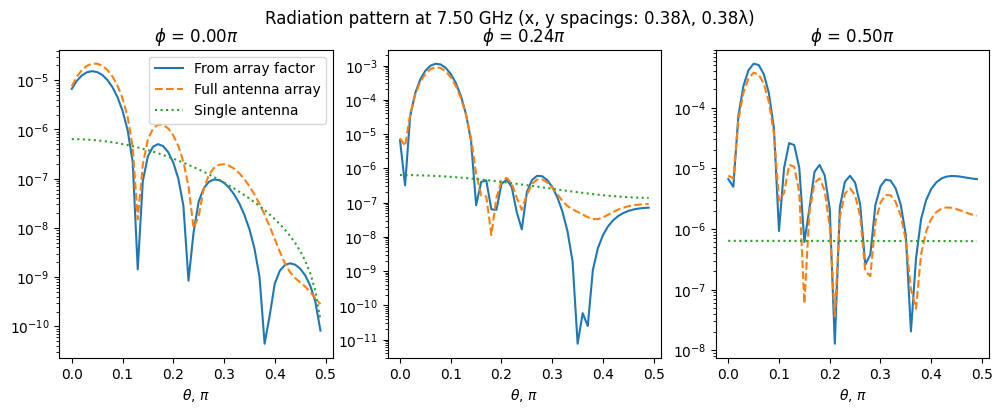

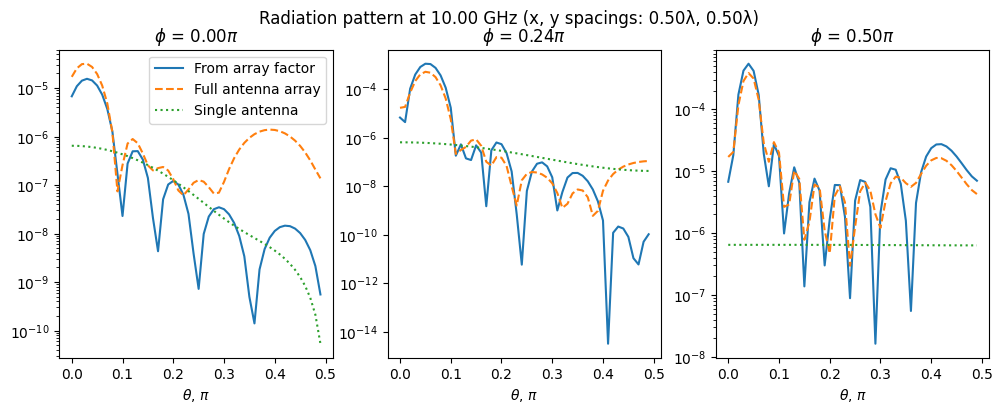

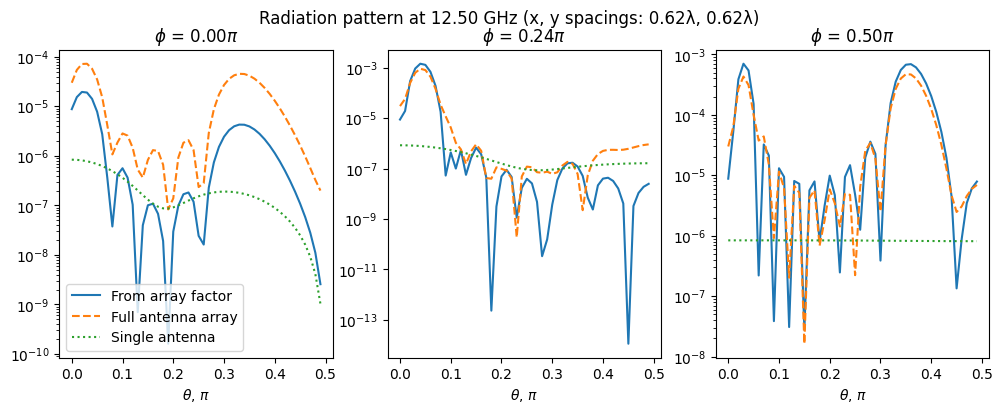

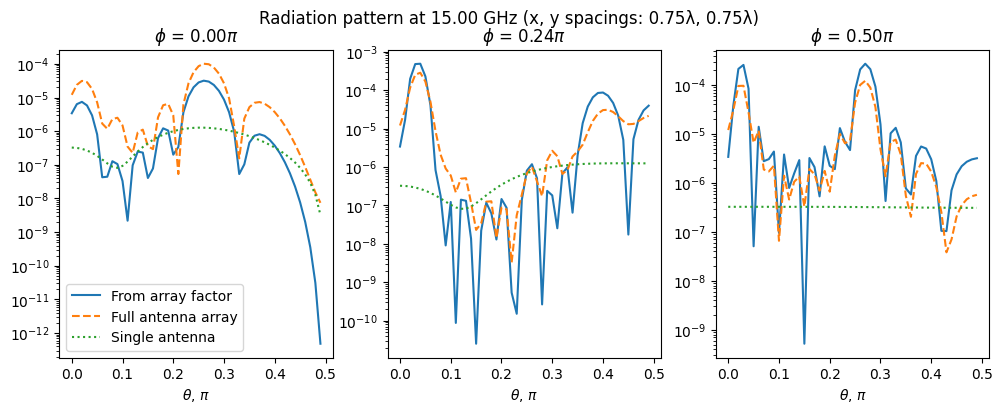

In [27]:
phi_plot_inds = [0, 12, 25]
num_phi_plots = len(phi_plot_inds)

for freq_plot in freqs_target:
    # create a new pyplot figure and 
    fig, axes = plt.subplots(1, num_phi_plots, figsize=(num_phi_plots * 4, 4))

    # compute current wavelength
    wavelength = td.C_0 / freq_plot

    # set title
    fig.suptitle(
        f"Radiation pattern at {freq_plot/1e9:.2f} GHz "
        f"(x, y spacings: {spacings[0]/wavelength:.2f}λ, {spacings[1]/wavelength:.2f}λ)",
    )

    for ind, ax in enumerate(axes):
        ax.set_title(f"$\phi$ = {phi[phi_plot_inds[ind]] / np.pi:.2f}$\pi$")
        ax.set_xlabel(r"$\theta$, $\pi$")

    def plot_data(data, label, style):
        for ind, ax in enumerate(axes):
            ax.semilogy(theta[0:50] / np.pi, np.abs(data[0:50, phi_plot_inds[ind]]), style, label=label)

    plot_data(sim_array_data_from_af["radiation"].power.sel(f=freq_plot).data[0], "From array factor", "-")
    plot_data(sim_array_data_direct["radiation"].power.sel(f=freq_plot).data[0], "Full antenna array", "--")
    plot_data(sim_unit_data["radiation"].power.sel(f=freq_plot).data[0], "Single antenna", ":")

    # plot_data(sim_array_data_from_af["directivity"].directivity.sel(f=freq_plot).data[0], "Full antenna array", "-")
    # plot_data(sim_array_data_direct["directivity"].directivity.sel(f=freq_plot).data[0], "From array factor", "--")
    # plot_data(sim_unit_data["directivity"].directivity.sel(f=freq_plot).data[0], "Single antenna", ":")

    # add legends
    axes[0].legend()

    plt.show()

